In [10]:
# 기본 세팅

import requests
import pandas as pd
import plotly.express as px
import time

API_KEY = ""

queries = [
    "숏드라마",
    "쇼츠",
    "숏폼",
    "숏폼",
    "숏드",
    "릴스"
]

negative_keywords = {
    "피로도": [
        "지겹", "지겨", "질림", "질려", "피로", "피곤", "지루"
    ],
    
    "반복성": [
        "반복", "똑같", "비슷", "맨날", "또 이거", "패턴", "항상 같은"
    ],
    
    "내용부족": [
        "내용없", "내용 없", "스토리 없", "뻔함", "유치", "노잼", "재미없"
    ],
    
    "자극성": [
        "자극", "억지", "오버", "과함", "선정적", "막장"
    ],
    
    "구조문제": [
        "너무 짧", "짧", "끊김", "흐름 이상", "전개 빠름"
    ],
    
    "광고/낚시": [
        "낚시", "어그로", "광고", "클릭베이트"
    ],
    
    "가치불만": [
        "시간낭비", "시간 낭비", "볼 가치 없음", "쓸데없"
    ]
}

In [11]:
# 영상 검색 함수

def search_videos(query, max_results=20):
    url = "https://www.googleapis.com/youtube/v3/search"
    
    params = {
        "key": API_KEY,
        "q": query,
        "part": "snippet",
        "type": "video",
        "maxResults": max_results,
        "regionCode": "KR"
    }
    
    res = requests.get(url, params=params)
    data = res.json()
    
    videos = []
    
    for item in data.get("items", []):
        video_id = item["id"]["videoId"]
        
        videos.append({
            "query": query,
            "video_id": video_id,
            "title": item["snippet"]["title"],
            "channel": item["snippet"]["channelTitle"],
            "link": f"https://www.youtube.com/watch?v={video_id}"
        })
    
    return videos

In [12]:
# 영상 수집 + 확인

all_videos = []

for q in queries:
    videos = search_videos(q, 15)
    all_videos.extend(videos)

df_videos = pd.DataFrame(all_videos)

# 중복 제거
df_videos = df_videos.drop_duplicates(subset="video_id")

print("영상 개수:", len(df_videos))
display(df_videos.head(10))

영상 개수: 70


,query,video_id,title,channel,link
0,숏드라마,xei_ufYgrQQ,🔥그녀는 한 달 후 차버릴 남자를 골랐다. 그런데 그 남자가 바로 자기 약혼자였다....,쿠키영상,https://www.youtube.com/watch?v=xei_ufYgrQQ
1,숏드라마,hPqvQkiEjzg,[놀면 뭐하니] 동생이 훔친 내 여자를 다시 뺏기로 했다 | 숏드라마 FULL버전,놀면 뭐하니?,https://www.youtube.com/watch?v=hPqvQkiEjzg
2,숏드라마,xCUE7XMBcsg,💥백화점에서 따귀 맞은 임산부… 남편 정체 공개되자 모두 무릎 꿇었다😱 #cdram...,StardustTV-한국,https://www.youtube.com/watch?v=xCUE7XMBcsg
3,숏드라마,izJqXpI4gy4,요즘 난리난 숏폼드라마 폭풍같은 결혼생활 숏츠 119편 계약 결혼 하고 보니 세계 ...,오디션타임즈 Audition Times,https://www.youtube.com/watch?v=izJqXpI4gy4
4,숏드라마,a_dMmhu8b8Q,미친ㅋㅋ 극한직업 팀이 다시 뭉쳐 숏 드라마를 만들면 벌어지는 일 ㅋㅋㅋ 개웃김,지무비 : G Movie,https://www.youtube.com/watch?v=a_dMmhu8b8Q
5,숏드라마,KKKNS3HBbaw,무당VS악마! #사탄여친 #topreels #drama #숏드라마 #movie #k...,탑릴스(TopReels),https://www.youtube.com/watch?v=KKKNS3HBbaw
6,숏드라마,q5KyDkp5VM4,"【더빙】독을 풀 수 있는 유일한 여자, 그녀와의 계약결혼으로 살아난 재벤 총수#mo...",달빛 극장🌙,https://www.youtube.com/watch?v=q5KyDkp5VM4
7,숏드라마,BePNd_Xy6dM,"🔥100분 몰아보기🔥남편X사촌 불륜 목격한 왕비, 죽고 나서 ‘무림고수’로 돌아왔다...",아시아앤 스튜디오 AsiaN STUDIO,https://www.youtube.com/watch?v=BePNd_Xy6dM
8,숏드라마,HqTCwUmznJU,의심한 남편의 살벌한 확인 사살 #비글루,숏드라마는 비글루 (Vigloo),https://www.youtube.com/watch?v=HqTCwUmznJU
9,숏드라마,IiR8aXtEUAE,"【더빙】지옥 같은 6년, 특훈소에서 돌아온 진짜 공딸의 복수.. &quot;내가 당...",달빛 극장🌙,https://www.youtube.com/watch?v=IiR8aXtEUAE


In [13]:
# 댓글 수집 함수

def get_comments(video_id, max_pages=3):
    url = "https://www.googleapis.com/youtube/v3/commentThreads"
    
    comments = []
    next_page_token = None
    
    for _ in range(max_pages):
        params = {
            "key": API_KEY,
            "videoId": video_id,
            "part": "snippet",
            "maxResults": 100
        }
        
        if next_page_token:
            params["pageToken"] = next_page_token
        
        res = requests.get(url, params=params)
        data = res.json()
        
        if "error" in data:
            break
        
        for item in data.get("items", []):
            text = item["snippet"]["topLevelComment"]["snippet"]["textDisplay"]
            comments.append(text)
        
        next_page_token = data.get("nextPageToken")
        
        if not next_page_token:
            break
        
        time.sleep(0.2)
    
    return comments

In [14]:
# 댓글 수집 + 데이터 생성

all_comments = []

for _, row in df_videos.iterrows():
    comments = get_comments(row["video_id"], max_pages=2)
    
    for c in comments:
        all_comments.append({
            "query": row["query"],
            "title": row["title"],
            "link": row["link"],
            "comment": c
        })

df_comments = pd.DataFrame(all_comments)

print("댓글 개수:", len(df_comments))
display(df_comments.head())

댓글 개수: 5740


,query,title,link,comment
0,숏드라마,🔥그녀는 한 달 후 차버릴 남자를 골랐다. 그런데 그 남자가 바로 자기 약혼자였다....,https://www.youtube.com/watch?v=xei_ufYgrQQ,잘봤어요.
1,숏드라마,🔥그녀는 한 달 후 차버릴 남자를 골랐다. 그런데 그 남자가 바로 자기 약혼자였다....,https://www.youtube.com/watch?v=xei_ufYgrQQ,왠일로 저남주 최고부자도련님으로 나왔나싶었는데 결론은 계속 빌런들한테 욕졸라처먹네 ...
2,숏드라마,🔥그녀는 한 달 후 차버릴 남자를 골랐다. 그런데 그 남자가 바로 자기 약혼자였다....,https://www.youtube.com/watch?v=xei_ufYgrQQ,여주이름뭐임
3,숏드라마,🔥그녀는 한 달 후 차버릴 남자를 골랐다. 그런데 그 남자가 바로 자기 약혼자였다....,https://www.youtube.com/watch?v=xei_ufYgrQQ,저 이소라같이 생긴 육덕녀 우와~~~~
4,숏드라마,🔥그녀는 한 달 후 차버릴 남자를 골랐다. 그런데 그 남자가 바로 자기 약혼자였다....,https://www.youtube.com/watch?v=xei_ufYgrQQ,저색퀴 남주로 쓰지마<br>혼자 씨익웃고 혼자말하고<br>끝나도 찝찝해


In [25]:
df_comments.to_csv("youtube_comments_raw.csv", index=False, encoding="utf-8-sig")

In [21]:
# 키워드 카테고리별 분석

result = []

for category, keywords in negative_keywords.items():
    count = 0

    for kw in keywords:
        count += df_comments["comment"].str.contains(kw, na=False, case=False).sum()

    result.append({
        "카테고리": category,
        "빈도": count
    })

df_category = pd.DataFrame(result)
df_category = df_category.sort_values(by="빈도", ascending=False)

display(df_category)

,카테고리,빈도
1,반복성,95
3,자극성,44
5,광고/낚시,31
4,구조문제,29
2,내용부족,25
0,피로도,15
6,가치불만,8


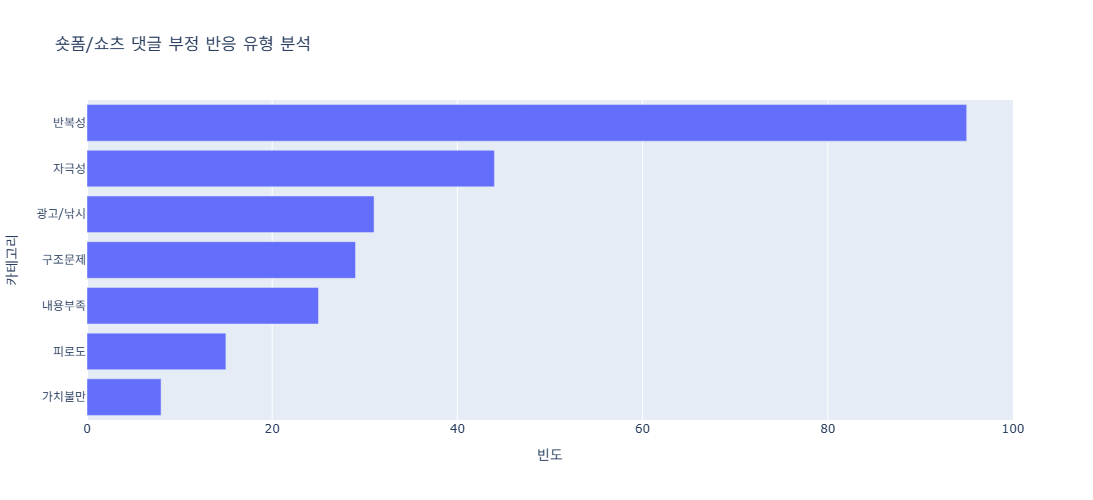

In [23]:
fig = px.bar(
    df_category[df_category["빈도"] > 0],
    x="빈도",
    y="카테고리",
    orientation="h",
    title="숏폼/쇼츠 댓글 부정 반응 유형 분석"
)

fig.update_layout(
    yaxis=dict(autorange="reversed"),
    width=800,
    height=500
)

fig.show()

In [28]:
result_detail = []

for category, keywords in negative_keywords.items():
    
    for kw in keywords:
        count = df_comments["comment"].str.contains(kw, na=False, case=False).sum()
        
        result_detail.append({
            "카테고리": category,
            "키워드": kw,
            "빈도": count
        })

df_detail = pd.DataFrame(result_detail)

# 0 제거 + 정렬
df_detail = df_detail[df_detail["빈도"] > 0]
df_detail = df_detail.sort_values(by="빈도", ascending=False)

display(df_detail)

,카테고리,키워드,빈도
8,반복성,똑같,40
9,반복성,비슷,27
34,광고/낚시,광고,26
28,구조문제,짧,25
10,반복성,맨날,21
26,자극성,막장,20
18,내용부족,유치,12
21,자극성,자극,11
22,자극성,억지,11
6,피로도,지루,10


In [29]:
matched_rows = []

for _, row in df_comments.iterrows():
    comment = str(row["comment"])
    
    matched_keywords = []
    matched_categories = []

    for category, keywords in negative_keywords.items():
        for kw in keywords:
            if kw.lower() in comment.lower():
                matched_keywords.append(kw)
                matched_categories.append(category)

    if matched_keywords:
        matched_rows.append({
            "query": row.get("query", ""),
            "title": row.get("title", ""),
            "link": row.get("link", ""),
            "comment": comment,
            "matched_category": ", ".join(sorted(set(matched_categories))),
            "matched_keyword": ", ".join(sorted(set(matched_keywords)))
        })

df_negative_comments = pd.DataFrame(matched_rows)

display(df_negative_comments)

,query,title,link,comment,matched_category,matched_keyword
0,숏드라마,[놀면 뭐하니] 동생이 훔친 내 여자를 다시 뺏기로 했다 | 숏드라마 FULL버전,https://www.youtube.com/watch?v=hPqvQkiEjzg,이한심한것들아 주접좀그만떨어라 안부끄럽니 이러고맨날!!,반복성,맨날
1,숏드라마,[놀면 뭐하니] 동생이 훔친 내 여자를 다시 뺏기로 했다 | 숏드라마 FULL버전,https://www.youtube.com/watch?v=hPqvQkiEjzg,약간 중국 드라마 광고 같애..ㅋㅌㅋㅋ,광고/낚시,광고
2,숏드라마,[놀면 뭐하니] 동생이 훔친 내 여자를 다시 뺏기로 했다 | 숏드라마 FULL버전,https://www.youtube.com/watch?v=hPqvQkiEjzg,몰입해서 입꼬리올라가고 보고있는 내가 짜증난닼ㅋㅋㅋㅋㅋㅋㅋㅋㅋ왜 쓸데없이 재밋냐,가치불만,쓸데없
3,숏드라마,[놀면 뭐하니] 동생이 훔친 내 여자를 다시 뺏기로 했다 | 숏드라마 FULL버전,https://www.youtube.com/watch?v=hPqvQkiEjzg,테무 광고 느낌임ㅋㅋㅋㅋ,광고/낚시,광고
4,숏드라마,[놀면 뭐하니] 동생이 훔친 내 여자를 다시 뺏기로 했다 | 숏드라마 FULL버전,https://www.youtube.com/watch?v=hPqvQkiEjzg,"<a href=""https://www.youtube.com/watch?v=hPqvQ...",광고/낚시,광고
...,...,...,...,...,...,...
219,릴스,인스타 400만 조회수 찍은 소주잔녀 영상,https://www.youtube.com/watch?v=I36kdsiJEQg,참 아이러니한 우리나라 음주문화<br>마시기 싫은데 억지로 먹이고<br>그걸보고 즐...,자극성,억지
220,릴스,릴스 100만 뷰 터지는 방법!? 알려드립니다.,https://www.youtube.com/watch?v=wfGWCvKZIvg,릴스가 잘되려면 최대한 짧은시간 안에 자극적인 걸 잘 담아야됨,"구조문제, 자극성","자극, 짧"
221,릴스,𝐏𝐥𝐚𝐲𝐥𝐢𝐬𝐭 SNS 대세 노래들 🔥 틱톡·릴스 인기 POP 모음 🎶 2026 트렌드,https://www.youtube.com/watch?v=7tmKQydeIKY,AI 노래 다 똑같음 ;; 진짜 싫다,반복성,똑같
222,릴스,릴스 3000만 영상,https://www.youtube.com/watch?v=nA1nCFlxBHU,노잼쩌노,내용부족,노잼


,카테고리,키워드,빈도
0,반복성,똑같,40
1,반복성,비슷,27
2,광고/낚시,광고,26
3,구조문제,짧,25
4,반복성,맨날,21
5,자극성,막장,20
6,내용부족,유치,12
7,자극성,자극,11
8,자극성,억지,11
9,피로도,지루,10


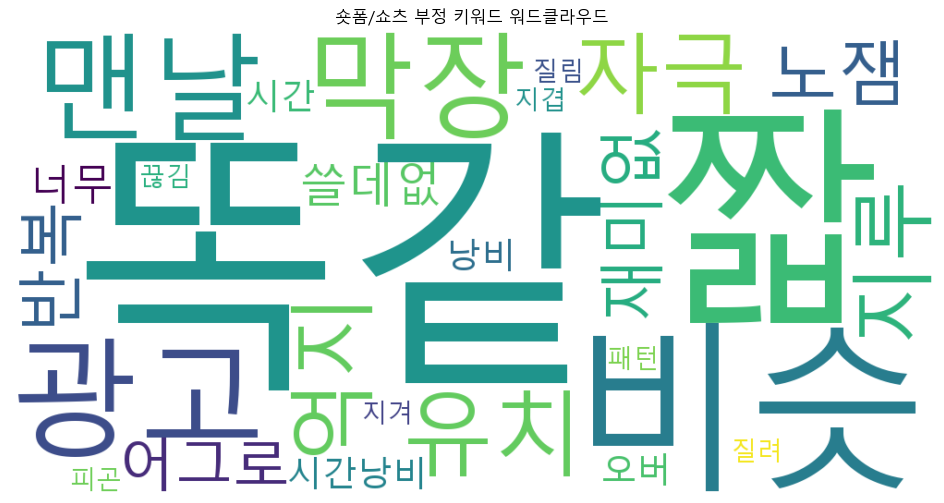

In [33]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 1. 세부 키워드 빈도표 만들기
result_detail = []

for category, keywords in negative_keywords.items():
    for kw in keywords:
        count = df_comments["comment"].str.contains(kw, na=False, case=False).sum()
        
        result_detail.append({
            "카테고리": category,
            "키워드": kw,
            "빈도": count
        })

df_detail = pd.DataFrame(result_detail)

# 빈도 0 제거
df_detail = df_detail[df_detail["빈도"] > 0]
df_detail = df_detail.sort_values(by="빈도", ascending=False).reset_index(drop=True)

display(df_detail)

# 2. 부정 키워드만으로 워드클라우드용 텍스트 만들기
keyword_text = " ".join(
    df_detail.apply(
        lambda row: (row["키워드"] + " ") * int(row["빈도"]),
        axis=1
    )
)

# 3. 워드클라우드 생성
wordcloud = WordCloud(
    font_path="C:/Windows/Fonts/malgun.ttf",
    width=1000,
    height=500,
    background_color="white",
    collocations=False
).generate(keyword_text)

# 4. 시각화
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("숏폼/쇼츠 부정 키워드 워드클라우드")
plt.show()